In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf 
import shutil
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## . Data Augmentation

Transformations appliquées pendant l'entraînement :
- Normalisation 
- Rotation (±20°)
- Flip horizontal
- Zoom (±15%)
- Translation horizontale/verticale (±10%)


In [ ]:
#On pointe sur le dossier qui contient tes images (qui est bien rempli)
ROOT_DIR = r'C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData'

# Construction des chemins
train_dir = os.path.join(ROOT_DIR, 'train')
val_dir = os.path.join(ROOT_DIR, 'val')
test_dir = os.path.join(ROOT_DIR, 'test')

# Vérification immédiate
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Erreur : Le dossier {train_dir} est introuvable. Vérifie le chemin.")

In [33]:
# 3. PRÉPARATION DES GÉNÉRATEURS ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Val et Test 
val_test_datagen = ImageDataGenerator(rescale=1./255)

#  4. CHARGEMENT DES DONNÉES 
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4099 images belonging to 2 classes.
Found 877 images belonging to 2 classes.
Found 880 images belonging to 2 classes.


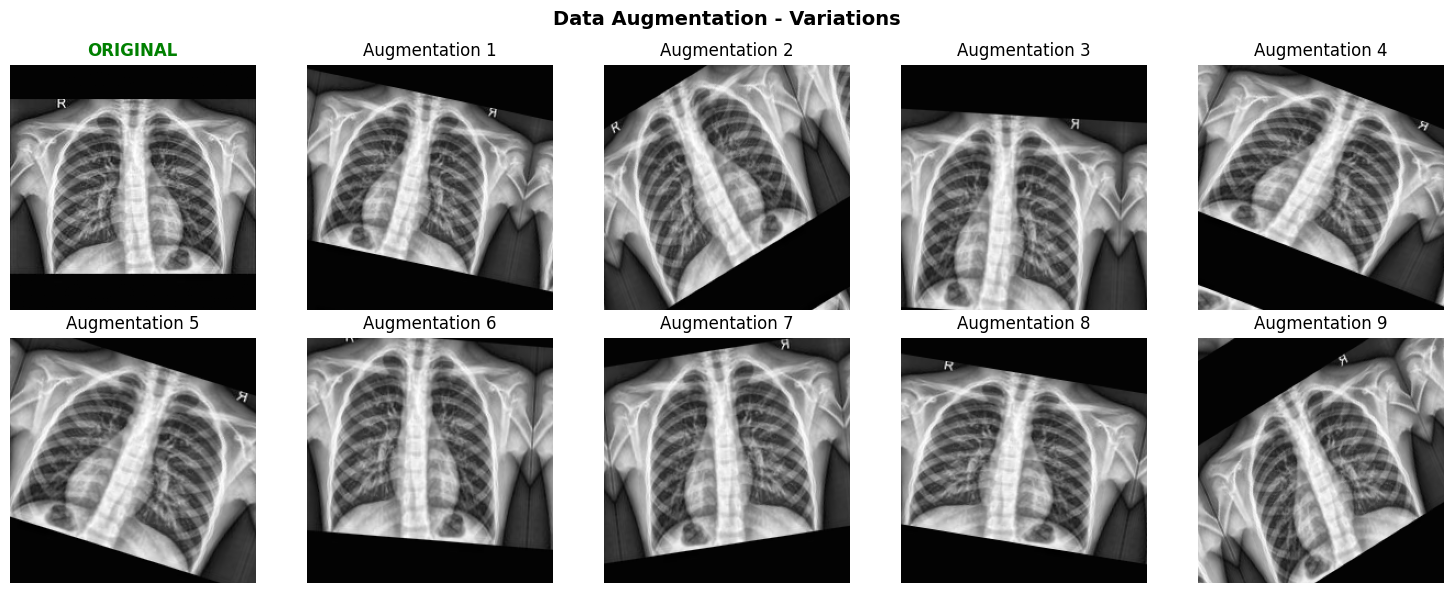

In [34]:
# On prend le premier sous-dossier et la première image dedans
subfolders = [f.path for f in os.scandir(train_dir) if f.is_dir()]
if subfolders:
    first_class_folder = subfolders[0]
    img_name = os.listdir(first_class_folder)[0]
    sample_img_path = os.path.join(first_class_folder, img_name)
    
    # 2. Charger l'image et la préparer pour le modèle
    img = load_img(sample_img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    # Ajouter la dimension de batch : (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0) 

    # 3. Visualisation
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    # Image originale (divisée par 255 pour affichage correct)
    axes[0].imshow(img_array[0] / 255.)
    axes[0].set_title('ORIGINAL', fontweight='bold', color='green')
    axes[0].axis('off')

    # Générer les augmentations
    aug_iter = train_datagen.flow(img_array, batch_size=1)

    for i in range(1, 10):
        aug_img = next(aug_iter)[0]
        axes[i].imshow(aug_img)
        axes[i].set_title(f'Augmentation {i}')
        axes[i].axis('off')

    plt.suptitle('Data Augmentation - Variations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Erreur : Impossible de trouver une image dans ton dossier train.")